# Event reconstruction for mono analysis

Our aim is to find the Hillas paramters for a simple monoscopic analysis.
refer to https://ctapipe.readthedocs.io/en/stable/auto_examples/tutorials/ctapipe_overview.html

For the file "gamma-diffuse_with_images_00.dl2.h5" 

Lets start with a bunch of imports...

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from ctapipe.io import EventSource
from ctapipe.visualization import CameraDisplay, ArrayDisplay
from ctapipe.reco import HillasReconstructor
from ctapipe.image import hillas_parameters, tailcuts_clean, timing_parameters
from ctapipe.image import brightest_island, number_of_islands
import math
import astropy.units as u
from astropy.coordinates import SkyCoord, AltAz
from ctapipe.coordinates import CameraFrame
from ctapipe.coordinates.utils import altaz_to_righthanded_cartesian


In [2]:
dl1_file = "gamma-diffuse_with_images_00.dl2.h5" 


source = EventSource(
    input_url = dl1_file,
    max_events = None
)
subarray = source.subarray


Table /configuration/simulation/run is missing column None for field run_number of container <class 'ctapipe.containers.SimulationConfigContainer'>. It will be skipped.


Find all events on any one telescope (lets say TEL_ID = 10)

- How many events are there?

In [3]:
mono_events = []
tel_id = 10
for event in source:
    if tel_id in event.dl1.tel:
        mono_events.append(event)
print(f"Number of events with telescope {tel_id} images: {len(mono_events)}")

Table /dl1/event/telescope/trigger is missing column event_type for field event_type of container <class 'ctapipe.containers.TelescopeTriggerContainer'>. It will be skipped.
Table /simulation/event/subarray/shower is missing column true_starting_grammage for field starting_grammage of container <class 'ctapipe.containers.SimulatedShowerContainer'>. It will be skipped.
Table /dl2/event/subarray/geometry/HillasReconstructor is missing column HillasReconstructor_ang_distance_uncert for field ang_distance_uncert of container <class 'ctapipe.containers.ReconstructedGeometryContainer'>. It will be skipped.
Table /dl1/event/telescope/parameters/tel_035 is missing column hillas_psi_uncertainty for field psi_uncertainty of container <class 'ctapipe.containers.HillasParametersContainer'>. It will be skipped.
Table /dl1/event/telescope/parameters/tel_035 is missing column hillas_transverse_cog_uncertainty for field transverse_cog_uncertainty of container <class 'ctapipe.containers.HillasParameter

Number of events with telescope 10 images: 7570


In [4]:
# You can find the image data in the dl1 file
mono_events[0].dl1.tel[tel_id].image

array([ 1.2, -1.3, -1.1, ...,  0.4, -0.6,  2.7],
      shape=(1855,), dtype=float32)

- Plot the image for different event ids
- Clean the image using `tailcuts_clean` (use event id = 5) - How to decide thresholds?
- Find the number of islands
- get the brightest island
- compute the Hillas parameters
- overlay the Hillas parameters on the plot
- Plot the arrival time at each pixel
- compute the timing profile using `timing_parameters`
- Repeat for another few events to get a feel
- Now, repeat for all events (for performance issues, use ~1000 events)
- Find the simulated energy value for each event
- Plot the Hillas/timing parameters with energy - The n

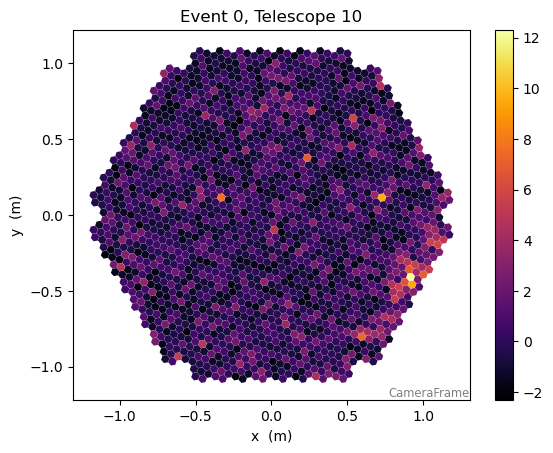

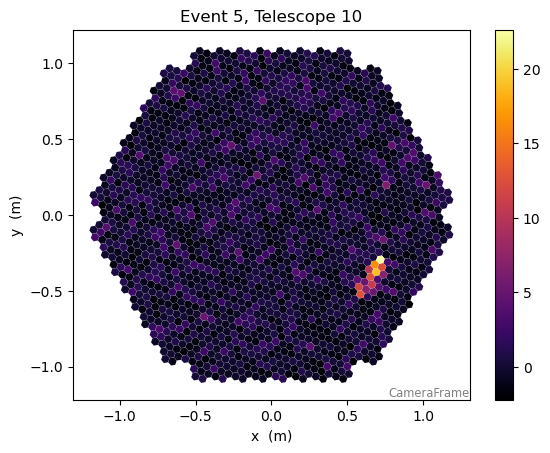

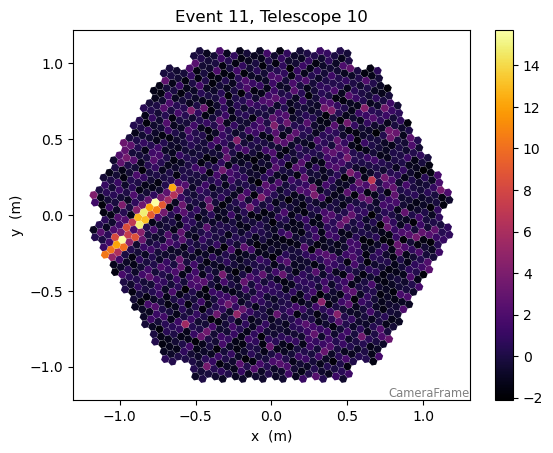

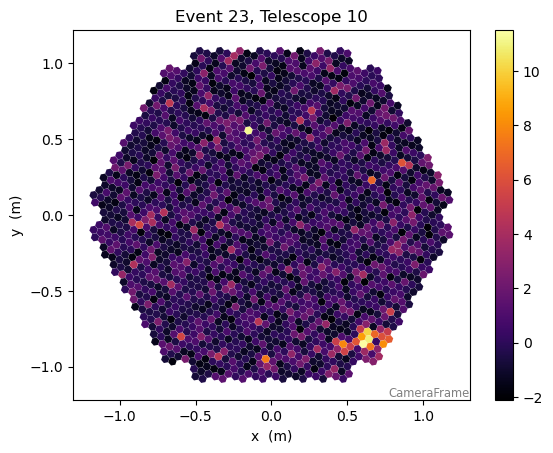

In [10]:
from ctapipe.visualization import CameraDisplay
import matplotlib.pyplot as plt

event_ids = [0, 5, 11, 23]
tel_id = 10

geom = source.subarray.tel[tel_id].camera.geometry

for i in event_ids:
    event = mono_events[i]
    
    image = event.dl1.tel[tel_id].image
    
    plt.figure()
    disp = CameraDisplay(geom, image=image)
    disp.add_colorbar()
    
    plt.title(f"Event {i}, Telescope {tel_id}")
    plt.show()

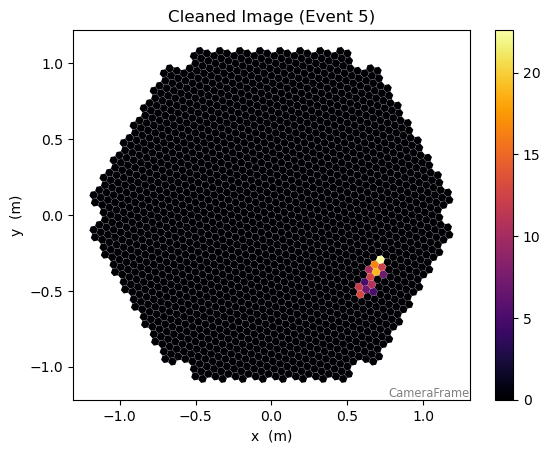

In [12]:
from ctapipe.image import tailcuts_clean
from ctapipe.visualization import CameraDisplay
import matplotlib.pyplot as plt

event_id = 5
tel_id = 10

event = mono_events[event_id]

image = event.dl1.tel[tel_id].image
geom = source.subarray.tel[tel_id].camera.geometry

clean_mask = tailcuts_clean(
    geom,
    image,
    picture_thresh=10,   
    boundary_thresh=5   
)

cleaned_image = image.copy()
cleaned_image[~clean_mask] = 0

plt.figure()
disp = CameraDisplay(geom, image=cleaned_image)
disp.add_colorbar()

plt.title(f"Cleaned Image (Event {event_id})")
plt.show()

In [18]:
'''Thresholds are chosen based on:

Noise level of camera:

Night sky background produces random noise
Threshold should be above noise fluctuations

Signal strength:
Cherenkov signal pixels are brighter
So i choose:
    
high threshold → real signal
low threshold → include neighbors'''

'Thresholds are chosen based on:\n\nNoise level of camera:\n\nNight sky background produces random noise\nThreshold should be above noise fluctuations\n\nSignal strength:\nCherenkov signal pixels are brighter\nSo i choose:\n    \nhigh threshold → real signal\nlow threshold → include neighbors'

In [14]:
from ctapipe.image import number_of_islands

n_islands, island_labels = number_of_islands(geom, clean_mask)

print(f"Number of islands: {n_islands}")

Number of islands: 1


In [19]:
'''After applying tailcuts_clean, only one island is found.
Hence, the brightest island coincides with the only island present.'''

'After applying tailcuts_clean, only one island is found.\nHence, the brightest island coincides with the only island present.'

In [20]:
from ctapipe.image import hillas_parameters

# compute Hillas parameters (use cleaned image)
hillas = hillas_parameters(geom, cleaned_image)

print(hillas)

{'intensity': np.float64(152.89999866485596),
 'kurtosis': np.float64(1.8610171221208414),
 'length': <Quantity 0.08457558 m>,
 'length_uncertainty': <Quantity 0.00317334 m>,
 'phi': <Angle -0.5367505 rad>,
 'psi': <Angle 1.0281727 rad>,
 'psi_uncertainty': <Angle 0.05619546 rad>,
 'r': <Quantity 0.77521606 m>,
 'skewness': np.float64(-0.34086483382918864),
 'transverse_cog_uncertainty': <Quantity 0.00368772 m>,
 'width': <Quantity 0.0265511 m>,
 'width_uncertainty': <Quantity 0.0014784 m>,
 'x': <Quantity 0.66620118 m>,
 'y': <Quantity -0.39640376 m>}


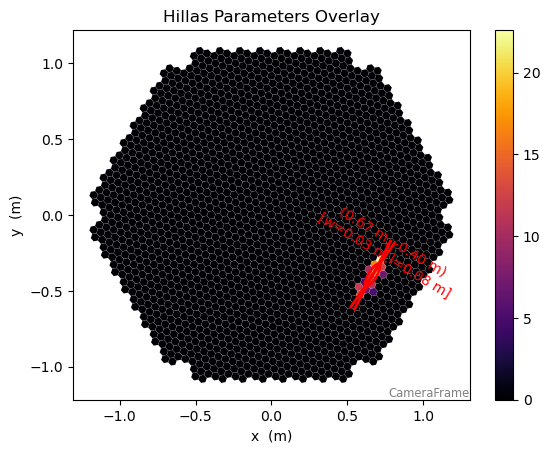

In [22]:
from ctapipe.visualization import CameraDisplay
import matplotlib.pyplot as plt

plt.figure()
disp = CameraDisplay(geom, image=cleaned_image)
disp.add_colorbar()

disp.overlay_moments(hillas, color='red', lw=2)

plt.title("Hillas Parameters Overlay")
plt.show()

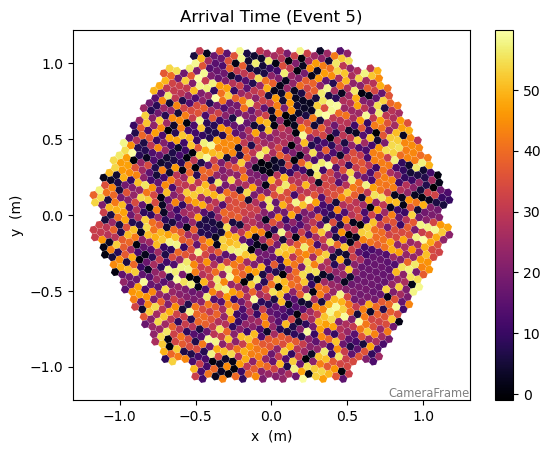

In [24]:
from ctapipe.visualization import CameraDisplay
import matplotlib.pyplot as plt

event_id = 5
tel_id = 10

event = mono_events[event_id]

geom = source.subarray.tel[tel_id].camera.geometry

time = event.dl1.tel[tel_id].peak_time
plt.figure()
disp = CameraDisplay(geom, image=time)
disp.add_colorbar()

plt.title(f"Arrival Time (Event {event_id})")
plt.show()

In [31]:
from ctapipe.image import timing_parameters

masked_image = image.copy()
masked_image[~clean_mask] = 0

masked_time = event.dl1.tel[tel_id].peak_time.copy()
masked_time[~clean_mask] = 0

timing_params = timing_parameters(
    geom,
    masked_image,
    masked_time,
    hillas
)

t_slope = timing_params.slope
t_intercept = timing_params.intercept
t_dev = timing_params.deviation

print(f"Timing Slope: {t_slope:.2f} ns/pixel")
print(f"Timing Intercept: {t_intercept:.2f} ns")
print(f"Timing Deviation: {t_dev:.2f} ns")

Timing Slope: 0.00 1 / m ns/pixel
Timing Intercept: 0.00 ns
Timing Deviation: 1.46 ns


In [34]:
from ctapipe.image import tailcuts_clean, hillas_parameters, timing_parameters

tel_id = 10
event_ids = [0, 5, 11, 23] 

geom = source.subarray.tel[tel_id].camera.geometry

for event_id in event_ids:
    event = mono_events[event_id]
    
    image = event.dl1.tel[tel_id].image
    time = event.dl1.tel[tel_id].peak_time
    
    clean_mask = tailcuts_clean(
        geom,
        image,
        picture_thresh=10,
        boundary_thresh=5
    )
    
    cleaned_image = image.copy()
    cleaned_image[~clean_mask] = 0
    
    hillas = hillas_parameters(geom, cleaned_image)
    
    masked_time = time.copy()
    masked_time[~clean_mask] = 0
    
    timing = timing_parameters(
        geom,
        cleaned_image,
        masked_time,
        hillas
    )
    
    print(f"\nEvent {event_id}")
    print(f"Length: {hillas.length:.3f}, Width: {hillas.width:.3f}")
    print(f"Slope: {timing.slope:.2f}, Deviation: {timing.deviation:.2f}")


Event 0
Length: 0.035 m, Width: 0.016 m
Slope: 0.00 1 / m, Deviation: 0.70

Event 5
Length: 0.085 m, Width: 0.027 m
Slope: 0.00 1 / m, Deviation: 1.46

Event 11
Length: 0.185 m, Width: 0.024 m
Slope: 0.00 1 / m, Deviation: 3.00

Event 23
Length: 0.036 m, Width: 0.034 m
Slope: 0.00 1 / m, Deviation: 0.97


In [1]:
energy_list = []
length_list = []
width_list = []
intensity_list = []
slope_list = []
deviation_list = []

In [51]:
energy_list = []

for event in mono_events:
    energy = event.simulation.shower.energy.value
    energy_list.append(energy)

print("Collected energies for", len(energy_list), "events")

Collected energies for 7570 events


In [52]:
def get_dl1_params(event, tel_id, geom):
    
    image = event.dl1.tel[tel_id].image
    time = event.dl1.tel[tel_id].peak_time

    clean_mask = tailcuts_clean(
        geom,
        image,
        picture_thresh=6,
        boundary_thresh=3
    )

    cleaned_image = image.copy()
    cleaned_image[~clean_mask] = 0

    if cleaned_image.sum() == 0:
        return None, None

    n_islands, island_labels = number_of_islands(geom, clean_mask)

    if n_islands == 0:
        return None, None

    brightest_mask = brightest_island(
        n_islands=n_islands,
        image=cleaned_image,
        island_labels=island_labels
    )

    hillas = hillas_parameters(
        geom[brightest_mask],
        cleaned_image[brightest_mask]
    )

    timing = timing_parameters(
        geom[brightest_mask],
        cleaned_image[brightest_mask],
        time[brightest_mask],
        hillas
    )

    return timing, hillas

In [56]:
time_slope_list = []
time_intercept_list = []
time_deviation_list = []
sim_energy_list = []
hillas_intensity_list = []
hillas_length_list = []
hillas_width_list = []

tel_id = 10
tel_geom = subarray.tel[tel_id].camera.geometry

for i, event in enumerate(mono_events):

    if i >= 1000:
        break

    result = get_dl1_params(event, tel_id, tel_geom)

    if result[0] is None:
        continue

    timing, hillas = result

    time_slope_list.append(timing.slope.value)
    time_intercept_list.append(timing.intercept)
    time_deviation_list.append(timing.deviation)

    sim_energy_list.append(event.simulation.shower.energy.value)

    hillas_intensity_list.append(hillas.intensity)
    hillas_length_list.append(hillas.length.value)
    hillas_width_list.append(hillas.width.value)

print("Collected:", len(sim_energy_list))

Collected: 1000


In [57]:
import numpy as np

time_slope_array = np.array(time_slope_list)
time_intercept_array = np.array(time_intercept_list)
time_deviation_array = np.array(time_deviation_list)
sim_energy_array = np.array(sim_energy_list)
hillas_intensity_array = np.array(hillas_intensity_list)
hillas_length_array = np.array(hillas_length_list)
hillas_width_array = np.array(hillas_width_list)

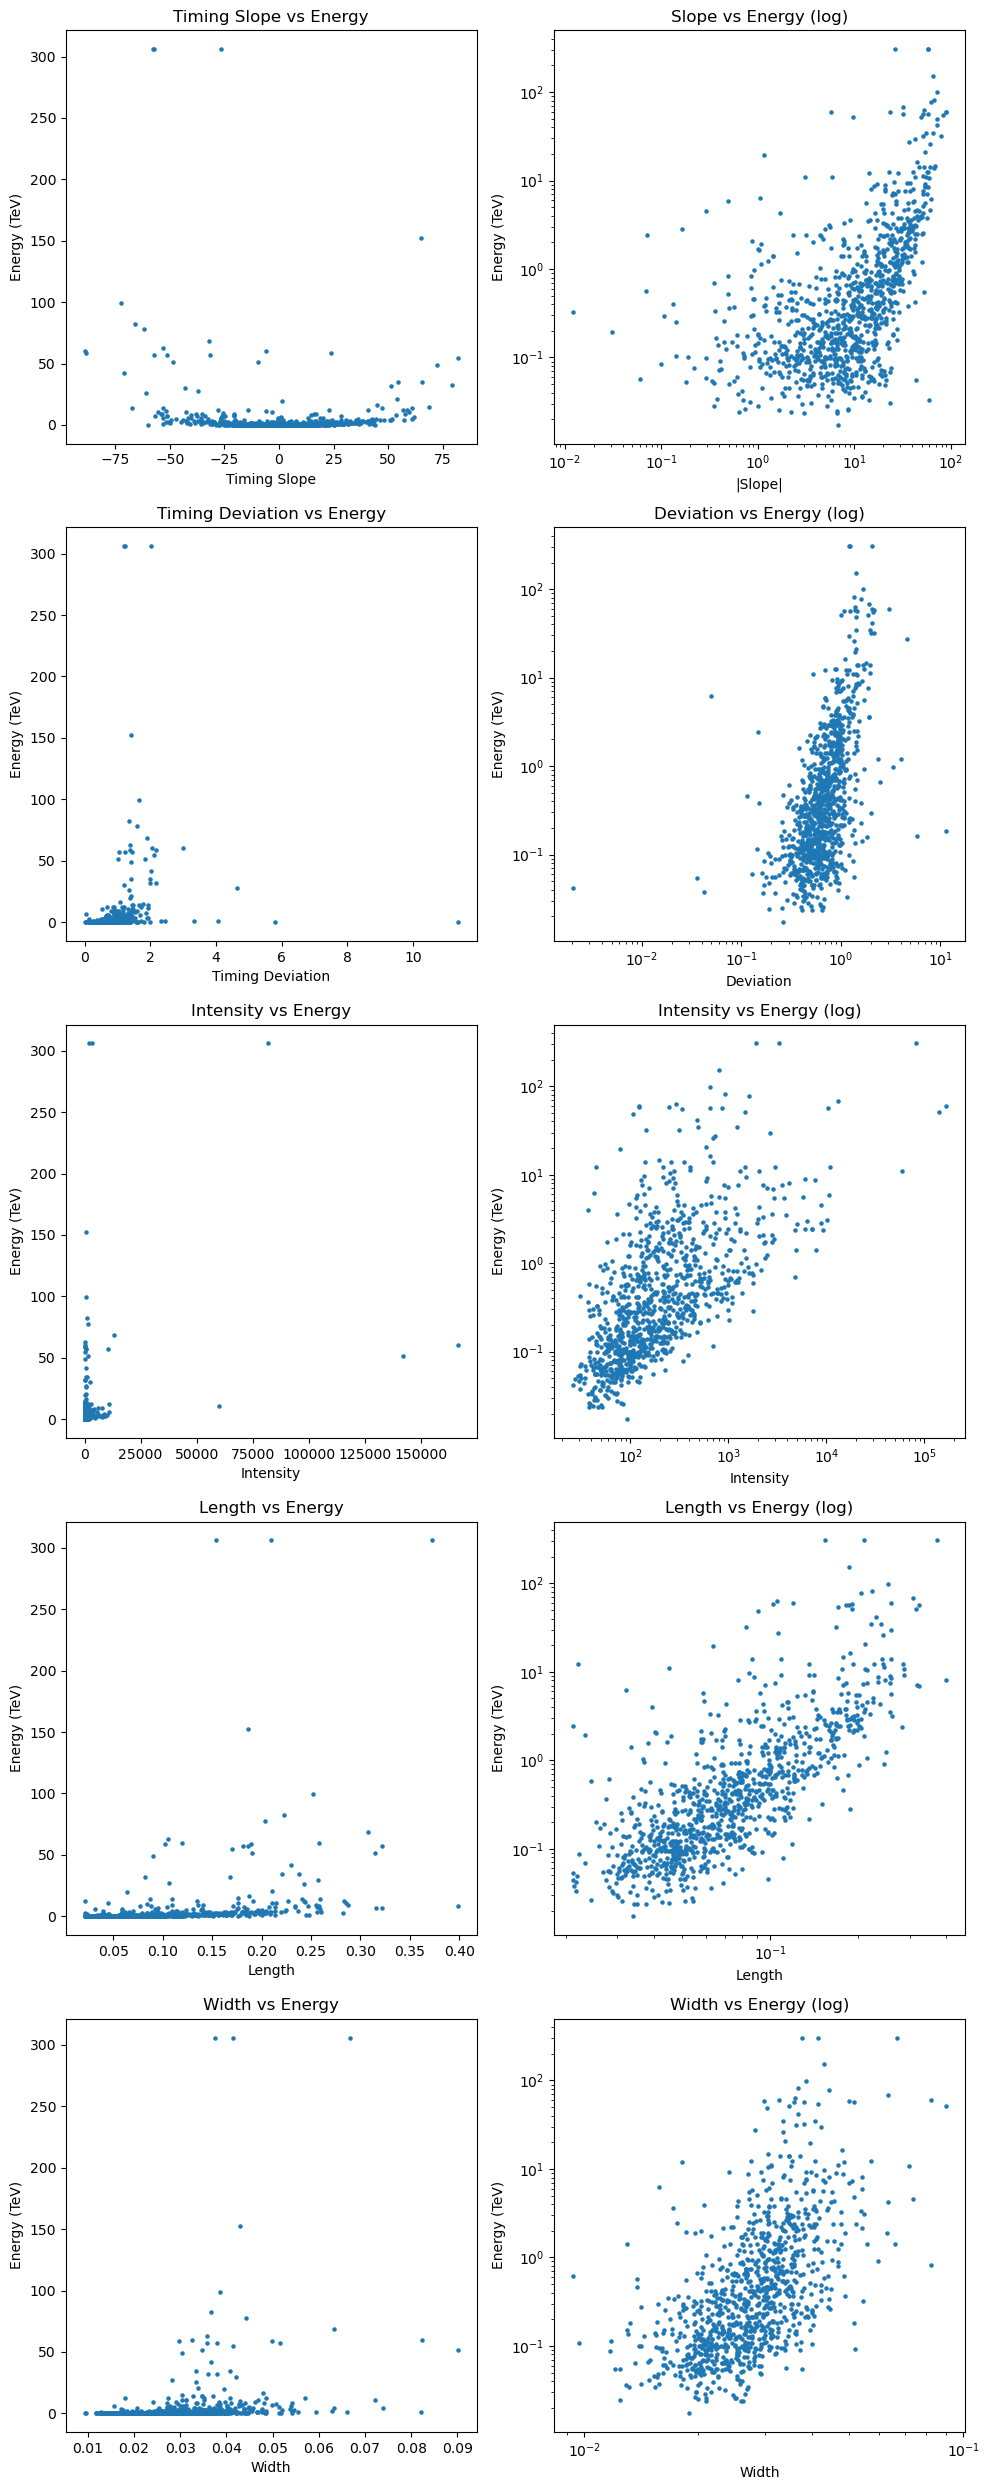

In [60]:
fig, ax = plt.subplots(5, 2, figsize=(10, 25))

# Timing slope
ax[0,0].scatter(time_slope_array, sim_energy_array, s=5)
ax[0,0].set_xlabel("Timing Slope")
ax[0,0].set_ylabel("Energy (TeV)")
ax[0,0].set_title("Timing Slope vs Energy")

# Timing deviation
ax[1,0].scatter(time_deviation_array, sim_energy_array, s=5)
ax[1,0].set_xlabel("Timing Deviation")
ax[1,0].set_ylabel("Energy (TeV)")
ax[1,0].set_title("Timing Deviation vs Energy")

#  Intensity
ax[2,0].scatter(hillas_intensity_array, sim_energy_array, s=5)
ax[2,0].set_xlabel("Intensity")
ax[2,0].set_ylabel("Energy (TeV)")
ax[2,0].set_title("Intensity vs Energy")

#  Length
ax[3,0].scatter(hillas_length_array, sim_energy_array, s=5)
ax[3,0].set_xlabel("Length")
ax[3,0].set_ylabel("Energy (TeV)")
ax[3,0].set_title("Length vs Energy")

#  Width
ax[4,0].scatter(hillas_width_array, sim_energy_array, s=5)
ax[4,0].set_xlabel("Width")
ax[4,0].set_ylabel("Energy (TeV)")
ax[4,0].set_title("Width vs Energy")



for i in range(5):
    ax[i,1].set_xscale('log')
    ax[i,1].set_yscale('log')

# slope (log)
ax[0,1].scatter(np.abs(time_slope_array), sim_energy_array, s=5)
ax[0,1].set_xlabel("|Slope|")
ax[0,1].set_ylabel("Energy (TeV)")
ax[0,1].set_title("Slope vs Energy (log)")

# deviation (log)
ax[1,1].scatter(time_deviation_array, sim_energy_array, s=5)
ax[1,1].set_xlabel("Deviation")
ax[1,1].set_ylabel("Energy (TeV)")
ax[1,1].set_title("Deviation vs Energy (log)")

# intensity (log)
ax[2,1].scatter(hillas_intensity_array, sim_energy_array, s=5)
ax[2,1].set_xlabel("Intensity")
ax[2,1].set_ylabel("Energy (TeV)")
ax[2,1].set_title("Intensity vs Energy (log)")

# length (log)
ax[3,1].scatter(hillas_length_array, sim_energy_array, s=5)
ax[3,1].set_xlabel("Length")
ax[3,1].set_ylabel("Energy (TeV)")
ax[3,1].set_title("Length vs Energy (log)")

# width (log)
ax[4,1].scatter(hillas_width_array, sim_energy_array, s=5)
ax[4,1].set_xlabel("Width")
ax[4,1].set_ylabel("Energy (TeV)")
ax[4,1].set_title("Width vs Energy (log)")

plt.tight_layout()
plt.show()

In [ ]:
'''From this exercise, I understood that gamma-ray showers produce elongated Cherenkov light images in the telescope camera, which can be characterized using Hillas parameters.

The plots show that the intensity of the image has the strongest correlation with the simulated energy, which is expected since higher energy gamma rays produce more secondary particles and hence more Cherenkov light.

The length of the image also increases with energy, indicating that higher energy showers develop deeper and spread more along the shower axis. The width also shows a positive correlation, but it is weaker compared to length, as the lateral spread of the shower is limited.

In contrast, the timing parameters (slope and deviation) show weaker correlations with energy and more scatter. This is reasonable because timing depends on fluctuations in shower development and geometry, making it less directly related to energy.'''



















